In [1]:
import numpy as np
import matplotlib.pyplot as plt

from pr3_utils import *
from tqdm import tqdm
from scipy.sparse import csr_matrix, lil_matrix
from cv2 import triangulatePoints

Part 1

In [2]:
dataset = "00"
filename = f"../data/dataset00/dataset{dataset}.npy"
imgs = f"../data/dataset00/dataset{dataset}_imgs.npy"

v_t, w_t, timestamps, features, K_l, K_r, extL_T_imu, extR_T_imu = load_data(filename)
features = features.T
images = np.load(imgs, allow_pickle=True).item()

In [3]:
print(f"Shape of linear velocities: {v_t.shape}")
print(f"Shape of angular velocities: {w_t.shape}")
print(f"Shape of timestamps: {timestamps.shape}")
print(f"Shape of features: {features.shape}")
print(f"Shape of K_l: {K_l.shape}")
print(f"Shape of K_r: {K_r.shape}")
print(f"Shape of extL_T_imu: {extL_T_imu.shape}")
print(f"Shape of extR_T_imu: {extR_T_imu.shape}")

Shape of linear velocities: (3755, 3)
Shape of angular velocities: (3755, 3)
Shape of timestamps: (3755,)
Shape of features: (3755, 5376, 4)
Shape of K_l: (3, 3)
Shape of K_r: (3, 3)
Shape of extL_T_imu: (4, 4)
Shape of extR_T_imu: (4, 4)


In [4]:
print(extL_T_imu)
print(extR_T_imu)

[[ 1.          0.          0.          0.02575617]
 [ 0.          1.          0.          0.02647408]
 [ 0.          0.          1.         -0.00914898]
 [ 0.          0.          0.          1.        ]]
[[ 1.          0.          0.          0.02565437]
 [ 0.          1.          0.         -0.06845528]
 [ 0.          0.          1.         -0.01070672]
 [ 0.          0.          0.          1.        ]]


In [5]:
baseline = extR_T_imu[1, 3] - extL_T_imu[1, 3]
K_s = np.zeros((4, 4))
print(K_l)
print(K_r)
K_s[:4, :3] = np.vstack((K_l[:2], K_r[:2]))
K_s[2, 3] = K_s[2, 0] * -baseline
print(K_s, baseline)

[[377.22922083   0.         326.35186498]
 [  0.         377.48656584 239.65966536]
 [  0.           0.           1.        ]]
[[377.53525716   0.         328.19337129]
 [  0.         377.20984138 240.42687894]
 [  0.           0.           1.        ]]
[[377.22922083   0.         326.35186498   0.        ]
 [  0.         377.48656584 239.65966536   0.        ]
 [377.53525716   0.         328.19337129  35.83918034]
 [  0.         377.20984138 240.42687894   0.        ]] -0.09492935999999999


3755
(480, 640)


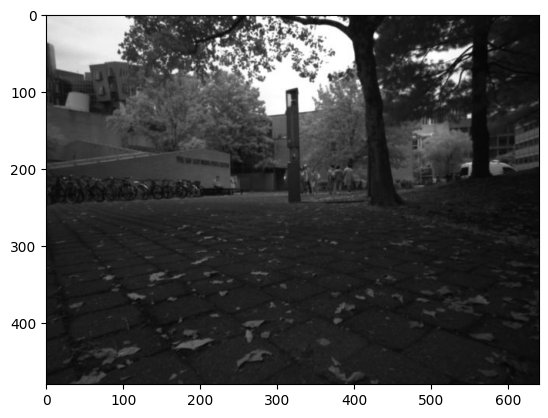

In [6]:
plt.imshow(images["cam_imgs_L"][0], cmap="gray")
print(len(images["cam_imgs_L"]))
print(images["cam_imgs_L"][0].shape)

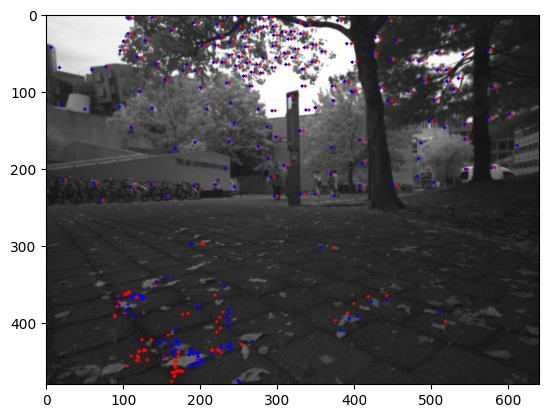

In [7]:
import cv2
def extract_features(features, img):
    for feature in features:
        for j in range(4):
            if feature[j] != -1:
                x = int(feature[0])
                y = int(feature[1])
                img = cv2.circle(img, (x, y), 2, (255, 0, 0), -1)

                x = int(feature[2])
                y = int(feature[3])
                img = cv2.circle(img, (x, y), 2, (0, 0, 255), -1)
    return img

img = images["cam_imgs_L"][60]
# Converting the image to RGB
img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
# Extracting the features
img = extract_features(features[60], img)
# Making the points colorful
plt.imshow(img)
plt.show()

In [8]:
def observed_features(features):
    observed = []
    for i in range(len(features)):
        feature = features[i]
        for j in range(4):
            if feature[j] != -1:
                observed.append(i)
                break
    return np.array(observed)

observed = observed_features(features[1000])
print(features[1000][observed])

[[ 4.77378235e+02  1.41141266e+02  4.76361755e+02  1.41227081e+02]
 [ 6.08346130e+02  9.52450485e+01  6.06640991e+02  9.53908768e+01]
 [ 5.89899109e+02  1.12828537e+02  5.88297913e+02  1.12964111e+02]
 [ 5.63398926e+02  6.50833359e+01  5.61917419e+02  6.52305908e+01]
 [ 5.65389587e+02 -4.70846748e+00  5.63837097e+02 -4.38251114e+00]
 [ 4.65525482e+02  7.39909668e+01  4.64491547e+02  7.41851044e+01]
 [ 4.77974060e+02  2.03168610e+02  4.76613556e+02  2.03226639e+02]
 [ 5.08539856e+02  1.82477341e+01  5.07345947e+02  1.83864899e+01]
 [ 5.75482971e+02  4.03657990e+01  5.74098694e+02  4.04244080e+01]
 [ 5.29717041e+02  4.44442825e+01  5.28443298e+02  4.45496979e+01]
 [ 4.64150024e+02  3.55040321e+01  4.63197632e+02  3.56172981e+01]
 [ 5.57697571e+02  6.42132721e+01  5.56268616e+02  6.43693390e+01]
 [ 5.09682739e+02  2.10804047e+02  5.07631775e+02  2.10866653e+02]
 [ 5.11800385e+02  1.25153679e+02  5.10569885e+02  1.25285263e+02]
 [ 4.81551239e+02  4.49241104e+01  4.80568451e+02  4.50078354e

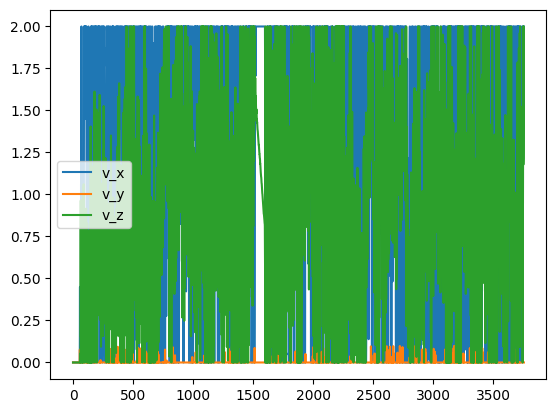

In [9]:
plt.plot(v_t[:, 0], label="v_x")
plt.plot(v_t[:, 1], label="v_y")
plt.plot(v_t[:, 2], label="v_z")
plt.legend()
plt.show()

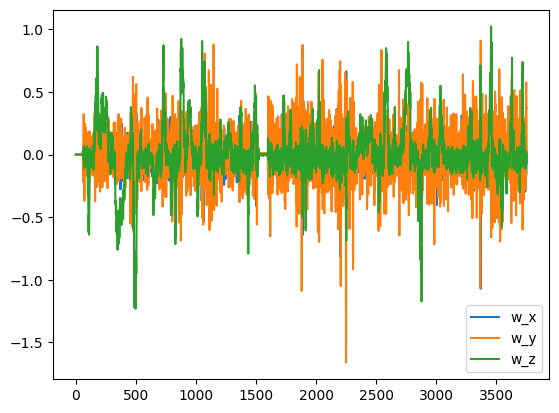

In [10]:
plt.plot(w_t[:, 0], label="w_x")
plt.plot(w_t[:, 1], label="w_y")
plt.plot(w_t[:, 2], label="w_z")
plt.legend()
plt.show()

In [11]:
def motion_model(v, w, dt, noise=0):
    """
    Compute the motion model for the robot
    :param v: linear velocity
    :param w: angular velocity
    :param dt: time step
    :return: the pose of the robot after the motion
    """
    # Compute the twist
    twist = axangle2twist(dt * np.hstack((v, w)))
    pose = twist2pose(twist)
    return pose

/Users/pedramaghazadeh/Desktop/ECE276a/Project3/code/pr3_utils.py:197: RuntimeWarning: invalid value encountered in divide
  Tn = np.nan_to_num(T / rotang)
/Users/pedramaghazadeh/Desktop/ECE276a/Project3/code/pr3_utils.py:197: RuntimeWarning: divide by zero encountered in divide
  Tn = np.nan_to_num(T / rotang)


(<Figure size 500x500 with 1 Axes>, <Axes: xlabel='x', ylabel='y'>)

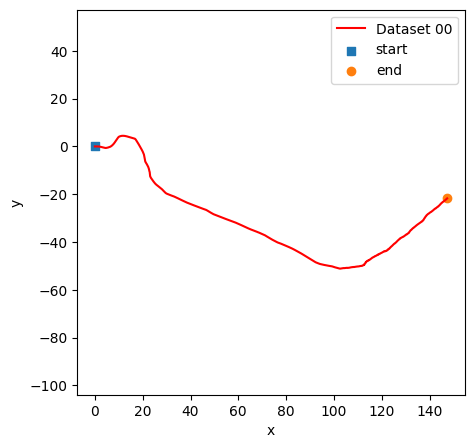

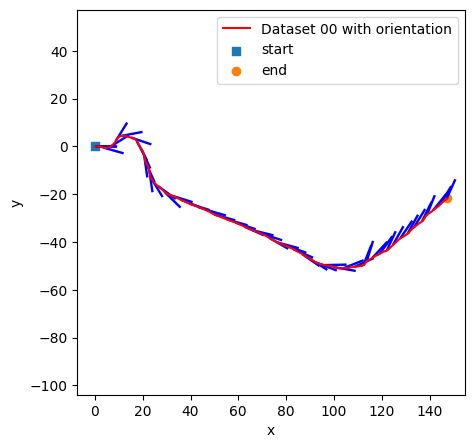

In [12]:
poses = np.zeros((v_t.shape[0], 4, 4))
poses[0] = np.eye(4)
for i in range(1, v_t.shape[0]):
    poses[i] = poses[i - 1] @ motion_model(v_t[i], w_t[i], timestamps[i] - timestamps[i-1])

visualize_trajectory_2d(poses, path_name="Dataset 00")
visualize_trajectory_2d(poses, path_name="Dataset 00 with orientation", show_ori=True)

In [13]:
def hat_map(x):
    """
    Compute the hat map of a vector
    :param x: the vector
    :return: the skew symmetric matrix
    """
    return np.array([[0, -x[2], x[1]],
                     [x[2], 0, -x[0]],
                     [-x[1], x[0], 0]])

# EKF SLAM
def ekf_predict(mu, sigma, v, w, dt):
    """
    EKF prediction step
    :param mu: the mean of the state
    :param sigma: the covariance of the state
    :param v: linear velocity
    :param w: angular velocity
    :param dt: time step
    :return: the predicted mean and covariance
    """
    f = motion_model(v, w, dt)
    mu_new = mu @ f
    
    u_hat = np.zeros((6, 6)) 
    u_hat[:3, :3] = hat_map(w)
    u_hat[:3, 3:] = hat_map(v)
    u_hat[3:, 3:] = hat_map(w)

    F = twist2pose(-dt * u_hat)
    sigma_new = F @ sigma @ F.T + dt * W
    return mu_new, sigma_new

(<Figure size 500x500 with 1 Axes>, <Axes: xlabel='x', ylabel='y'>)

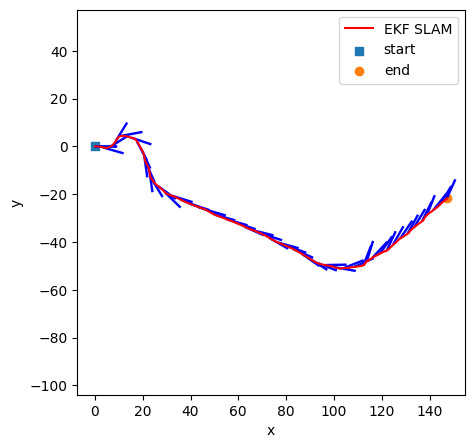

In [14]:
noise = 0.01
W = np.diag([noise, noise, noise, noise, noise, noise])

pose_means = np.zeros((v_t.shape[0], 4, 4))
pose_covs = np.zeros((v_t.shape[0], 6, 6))
pose_means[0] = np.eye(4)
pose_covs[0] = np.eye((6))

for i in range(1, v_t.shape[0]):
    pose_means[i], pose_covs[i] = ekf_predict(pose_means[i - 1], pose_covs[i - 1], v_t[i], w_t[i], timestamps[i] - timestamps[i-1])

visualize_trajectory_2d(pose_means, path_name="EKF SLAM", show_ori=True)

Part c)

In [ ]:
opt_T_imu = np.zeros((4, 4))
opt_T_imu[0, 1] = -1
opt_T_imu[1, 2] = -1
opt_T_imu[2, 0] = 1
opt_T_imu[3, 3] = 1

def pi(x):
    """
    Project x
    :param x: the vector to project
    :return: the projected vector
    """
    return x / x[2]


def jacobian_pi(x):
    """
    Compute the Jacobian of the projection
    :param x: the vector to project
    :return: the Jacobian
    """
    J = np.zeros((4, 4))
    J[0, 0] = 1 / x[2]
    J[1, 1] = 1 / x[2]
    J[0, 2] = -x[0] / x[2]**2
    J[1, 2] = -x[1] / x[2]**2
    J[2, 3] = -x[3] / x[2]**2
    J[3, 3] = 1 / x[2]
    return J

def observation_model(pose, m):
    """
    Compute the observation model
    :param mu: the mean of the state
    :param feature: the feature
    :return: the expected measurement
    """
    # Homogeneous coordinates
    m_ = np.ones(4)
    m_[:3] = m

    pose_inv = np.linalg.inv(pose)
    z = K_s @ pi(opt_T_imu @ pose_inv @ m_)

    return z

def jacobian_observation_model(pose, mu):
    """
    Compute the Jacobian of the observation model
    :param mu: the mean of the state"
    """
    # Homogeneous coordinates
    m_ = np.ones(4)
    m_[:3] = mu

    P = np.zeros((3, 4))
    P[:3, :3] = np.eye(3)

    pose_inv = np.linalg.inv(pose)
    jacobian = K_s @ jacobian_pi(opt_T_imu @ pose_inv @ m_) @ opt_T_imu @ pose_inv @ P.T

    return jacobian

In [16]:
print(observation_model(np.eye(4), np.array([21, 212, 3])))

[-3481.86693579   185.7330131  -3481.4083115    186.53975874]


In [17]:
N_feature = features.shape[1]
mean_features = np.zeros((N_feature * 3))
cov_features = np.eye(N_feature * 3) # Very large covariance, but only 3*3 diagonal blocks are used

obs_noise = 0.1
cov_noise_obs = np.zeros((4 * N_feature, 4 * N_feature))
for j in range(N_feature):
    cov_noise_obs[4 * j:4 * j + 4, 4 * j:4 * j + 4] = np.diag([obs_noise, obs_noise, obs_noise, obs_noise])

In [18]:
print(extL_T_imu @ inversePose(extR_T_imu))
print(extR_T_imu[:3, 3] - extL_T_imu[:3, 3])

[[1.000000e+00 0.000000e+00 0.000000e+00 1.018000e-04]
 [0.000000e+00 1.000000e+00 0.000000e+00 9.492936e-02]
 [0.000000e+00 0.000000e+00 1.000000e+00 1.557740e-03]
 [0.000000e+00 0.000000e+00 0.000000e+00 1.000000e+00]]
[-0.0001018  -0.09492936 -0.00155774]


Triangulation for the initial guess

100%|██████████| 3755/3755 [00:03<00:00, 952.95it/s] 


(<Figure size 500x500 with 1 Axes>, <Axes: xlabel='x', ylabel='y'>)

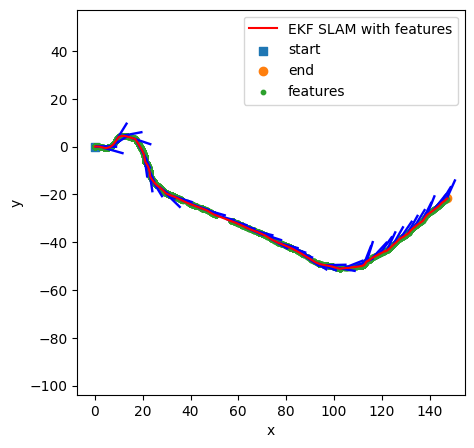

In [29]:
opt_R_imu = np.zeros((3, 3))
opt_R_imu[0, 1] = -1
opt_R_imu[1, 2] = -1
opt_R_imu[2, 0] = 1

temp = np.zeros((3, 4))
temp[:3, :3] = np.eye(3)


p_l = temp
p = extL_T_imu[:3, 3] - extR_T_imu[:3, 3]
temp[:3, 3] = -p
p_r = temp

marked = [0] * N_feature

l_inv = np.linalg.inv(K_l)
r_inv = np.linalg.inv(K_r)

# Adding the initial guesses
for i in tqdm(range(len(pose_means))):
    pose = pose_means[i]
    for j in range(N_feature):
        if marked[j] == 0:
            feature = features[i, j]
            for k in range(4):
                if feature[k] != -1:
                    # CV2 method
                    normalized_l = l_inv @ np.array([feature[0], feature[1], 1])
                    normalized_r = r_inv @ np.array([feature[2], feature[3], 1])
                    

                    point = triangulatePoints(p_l, p_r, normalized_l[:2], normalized_r[:2]) # Robot frame
                    point = (point / point[3]).flatten()
                    # point = np.array([[0, 1, 0, 0], [1, 0, 0, 0], [0, 0, 1, 0], [0, 0, 0, 1]]) @ point
                    point = pose @ inversePose(opt_T_imu) @ opt_T_imu @ point
                    # From slides
                    # z_l = np.ones(3)
                    # z_l[:2] = feature[:2]
                    # z_r = np.ones(3)
                    # z_r[:2] = feature[2:]

                    # print(z_l, z_r)
                    # z_l = l_inv @ z_l
                    # z_r = r_inv @ z_r
                    
                    # a = (p - p[2] * z_r)
                    # b = (z_l - z_r)
                    # depth = (a.T @ a) / (a.T @ b)
                    # point = z_l * depth

                    # point_ = np.ones(4)
                    # point_[:3] = point

                    # point =  pose @ inversePose(extL_T_imu) @ opt_T_imu @ point_
                    mean_features[3 * j:3 * j + 3] = point[:3]
                    marked[j] = 1
                    break
visualize_trajectory_2d(pose_means, path_name="EKF SLAM with features", show_ori=True, features=mean_features.reshape(-1, 3))

In [20]:
for i in tqdm(range(200)):
    observed = observed_features(features[i])
    if len(observed) == 0:
        continue

    z = features[i][observed].flatten() # N_t x 4
    z_hat = np.zeros((4 * len(observed)))

    H = lil_matrix((4 * len(observed), 3 * N_feature))
    V = cov_noise_obs[: 4 * len(observed), : 4 * len(observed)]

    for idx, feature_idx in enumerate(observed):
        feature_slice = slice(3 * feature_idx, 3 * feature_idx + 3)
        obs_slice = slice(4 * idx, 4 * idx + 4)

        z_hat[obs_slice] = observation_model(pose_means[i], mean_features[feature_slice])
        H[obs_slice, feature_slice] = jacobian_observation_model(pose_means[i], mean_features[feature_slice])

    H = H.tocsr()
    cov_features = csr_matrix(cov_features)

    S = H @ cov_features @ H.T + V
    S_inv = np.linalg.inv(S)
    K = cov_features @ H.T @ csr_matrix(S_inv)
    I = csr_matrix(np.eye(N_feature * 3))

    cov_features = (I - K @ H) @ cov_features
    mean_features = mean_features + K @ (z - z_hat)

visualize_trajectory_2d(pose_means, path_name="EKF SLAM with features", show_ori=True, features=np.clip(mean_features.reshape(-1, 3), -150, 150))
    

 30%|███       | 61/200 [00:04<00:09, 14.50it/s] 


KeyboardInterrupt: 